# 04. Evaluación Inicial: SLM vs LLM vs RAG Dual (LLM-as-a-Judge)

## Objetivos del Notebook
Este notebook ejecuta la una primera prueba del TFG sometiendo una batería de 80 preguntas (CSV) a 4 configuraciones distintas:
1. **SLM Base (Local):** Phi-3-mini-4k-instruct respondiendo de memoria (sin RAG).
2. **LLM Avanzado (Nube):** Llama 3 70B respondiendo de memoria (sin RAG).
3. **RAG Léxico (BM25 + SLM):** Nuestro sistema RAG tradicional usando palabras clave.
4. **RAG Semántico (Vectores + SLM):** Nuestro sistema RAG usando embeddings (BGE-M3) y kNN.

## Metodología de Evaluación
Utilizaremos el paradigma **LLM-as-a-Judge**. Un modelo(`openai/gpt-oss-120b`) leerá la "Respuesta Esperada" de nuestro CSV y la comparará con la respuesta generada por cada uno de los 4 sistemas. Evaluará si la esencia de la respuesta es "CORRECTA" o "INCORRECTA". Finalmente, visualizaremos los resultados en un gráfico de barras.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Cargamos variables de entorno (Asegúrate de que en tu .env ponga GROQ_API_KEY=tu_clave)
load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if not GROQ_API_KEY:
    print("ADVERTENCIA: No se encontró GROQ_API_KEY en el entorno.")
else:
    print("API Key de Groq cargada correctamente.")

API Key de Groq cargada correctamente.


In [2]:
import torch
from elasticsearch import Elasticsearch
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# 1. Cargamos el CSV con las preguntas
# (Asegúrate de que las columnas se llamen 'Pregunta' y 'Respuesta_Esperada')
df_preguntas = pd.read_csv("bateria_preguntas_tfg.csv")
print(f"Batería de preguntas cargada: {len(df_preguntas)} preguntas listas para evaluar.")

# 2. Inicializamos Infraestructura Local
print("Conectando a Elasticsearch...")
es = Elasticsearch("http://127.0.0.1:9250")
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Cargando BGE-M3 (Vectores)...")
embed_model = SentenceTransformer('BAAI/bge-m3', device=device)

print("Cargando Phi-3 (SLM)...")
MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=False)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, device_map="auto", torch_dtype=torch.float16)
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

# 3. INYECCIÓN EN RAG_ENGINE
import rag_engine
rag_engine.es = es
rag_engine.embed_model = embed_model
rag_engine.pipe = pipe

print("Modelos locales cargados y enlazados a rag_engine.py")

/home/javierruiz/miniconda3/envs/environment/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Batería de preguntas cargada: 80 preguntas listas para evaluar.
Conectando a Elasticsearch...
Cargando BGE-M3 (Vectores)...


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 3105.39it/s, Materializing param=pooler.dense.weight]                               


Cargando Phi-3 (SLM)...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 195/195 [00:01<00:00, 125.62it/s, Materializing param=model.norm.weight]                              


Sistema RAG (k=1) reconfigurado para devolver datos separados.
Sistema RAG Vectorial (k=1) configurado.
Modelos locales cargados y enlazados a rag_engine.py


In [3]:
df_preguntas.head()

,id,tipo,pregunta,respuesta_esperada
0,1,Factual,¿A cuanto llego a subir Trump los aranceles a ...,145%.
1,2,Factual,¿Cuánto dinero perdió Elon Musk tras el anunci...,17.800 millones de dólares.
2,3,Trampa,¿Qué opinó el Rey de España sobre los arancele...,No tengo información suficiente en mis archivos.
3,4,Trampa,¿Qué declaraciones hizo Elon Musk sobre los ar...,No tengo información suficiente en mis archivos.
4,5,Inferencia,¿Qué relación quiere Elon Musk entre Estados U...,Quiere una zona de libre comercio con arancele...


In [4]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 1. El LLM Avanzado (Caso 2: Llama 3 70B)
llm_avanzado = ChatGroq(
    model="llama-3.3-70b-versatile", 
    temperature=0, # Determinista
    api_key=GROQ_API_KEY
)

# 2. El Juez
llm_juez = ChatGroq(
    #model="llama-3.1-8b-instant",
    model="openai/gpt-oss-120b", 
    temperature=0, 
    api_key=GROQ_API_KEY
)

prompt_evaluacion = ChatPromptTemplate.from_messages([
    ("system", """Eres un Juez de Veracidad para un sistema RAG. 
    Tu única misión es validar si la 'Respuesta Generada' coincide con la 'Respuesta Esperada'.

    REGLAS DE ORO:
    1. La respuesta generada puede ser CORRECTA aunque este redactada de forma diferente, siempre que transmita el mismo dato o información esencial que la respuesta esperada.
    2. No uses tu propio conocimiento externo para validar la respuesta, ciñete a la comparación entre la respuesta esperada y la generada.

    Responde ÚNICAMENTE con la palabra "CORRECTO" o "INCORRECTO"."""),
    ("human", "Respuesta Esperada:\n{esperada}\n\nRespuesta Generada por el RAG:\n{generada}")
])

juez_chain = prompt_evaluacion | llm_juez | StrOutputParser()
print("Modelos de Groq (Llama 3) y Sistema de Evaluación Juez configurados.")

Modelos de Groq (Llama 3) y Sistema de Evaluación Juez configurados.


In [5]:
from langchain_core.messages import SystemMessage, HumanMessage

def caso1_slm_base(pregunta):
    """Caso 1: Phi-3 responde de memoria (con límite de verbosidad)"""
    messages = [
        {"role": "system", "content": "Eres un asistente directo. Responde a la pregunta de manera muy breve y concisa."},
        {"role": "user", "content": pregunta}
    ]
    out = pipe(messages, do_sample=False) 
    return out[0]['generated_text'][-1]['content'].strip()

def caso2_llm_avanzado(pregunta):
    """Caso 2: Llama 3 70B responde de memoria (con límite de verbosidad)"""
    messages = [
        SystemMessage(content="Eres un asistente directo. Responde a la pregunta de manera muy breve y concisa."),
        HumanMessage(content=pregunta)
    ]
    respuesta = llm_avanzado.invoke(messages)
    return respuesta.content.strip()
def caso3_rag_bm25(pregunta):
    """Caso 3: RAG Léxico con Phi-3"""
    resultado = rag_engine.ask_rag(pregunta, top_k=2)
    return resultado.get('respuesta_rag', resultado.get('error', 'Error desconocido'))

def caso4_rag_vectorial(pregunta):
    """Caso 4: RAG Semántico con Phi-3"""
    resultado = rag_engine.ask_rag_vectorial(pregunta, top_k=2)
    return resultado.get('respuesta_rag', resultado.get('error', 'Error desconocido'))

In [6]:
import transformers
import warnings

# 1. Silenciamos la charla interna de Hugging Face (solo mostrará errores críticos)
transformers.logging.set_verbosity_error()

# 2. Silenciamos los avisos estándar de Python
warnings.filterwarnings("ignore")

In [7]:
import time
from tqdm import tqdm
print("Ping a Elasticsearch:", es.ping())
resultados = []

print("Iniciando evaluación de los 4 casos para cada pregunta...")

# Iteramos sobre el CSV (usamos tqdm para ver la barra de progreso)
for index, row in tqdm(df_preguntas.iterrows(), total=len(df_preguntas)):
    pregunta = row['pregunta']
    esperada = row['respuesta_esperada']
    
    # 1. Generamos las 4 respuestas
    resp_c1 = caso1_slm_base(pregunta)
    resp_c2 = caso2_llm_avanzado(pregunta)
    resp_c3 = caso3_rag_bm25(pregunta)
    resp_c4 = caso4_rag_vectorial(pregunta)
    
    # 2. El Juez evalúa las 4 respuestas
    eval_c1 = juez_chain.invoke({"esperada": esperada, "generada": resp_c1}).strip().upper()
    eval_c2 = juez_chain.invoke({"esperada": esperada, "generada": resp_c2}).strip().upper()
    eval_c3 = juez_chain.invoke({"esperada": esperada, "generada": resp_c3}).strip().upper()
    eval_c4 = juez_chain.invoke({"esperada": esperada, "generada": resp_c4}).strip().upper()
    
    # 3. Guardamos en el registro
    resultados.append({
        "Pregunta": pregunta,
        "Esperada": esperada,
        "C1_SLM_Resp": resp_c1, "C1_Eval": eval_c1,
        "C2_LLM_Resp": resp_c2, "C2_Eval": eval_c2,
        "C3_BM25_Resp": resp_c3, "C3_Eval": eval_c3,
        "C4_VECT_Resp": resp_c4, "C4_Eval": eval_c4
    })
    
    # Pequeña pausa para no saturar la API gratuita de Gemini
    time.sleep(1) 

# Convertimos a DataFrame para analizar cómodamente
df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv("resultados_evaluacion_tfg.csv", index=False)
print("Evaluación terminada. Resultados guardados en 'resultados_evaluacion_tfg.csv'.")

Ping a Elasticsearch: True
Iniciando evaluación de los 4 casos para cada pregunta...


100%|██████████| 80/80 [25:46<00:00, 19.33s/it]

Evaluación terminada. Resultados guardados en 'resultados_evaluacion_tfg.csv'.


/tmp/ipykernel_3558348/689997832.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=porcentajes, y=nombres, palette="viridis")


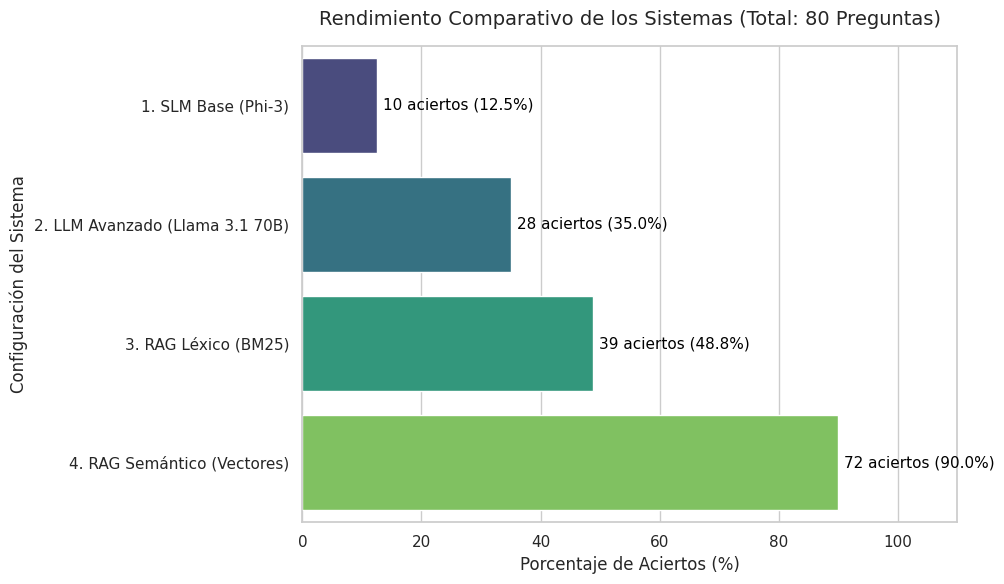

In [3]:
# Contamos cuántos "CORRECTO" sacó cada modelo
df_resultados = pd.read_csv("resultados_evaluacion_tfg_inicial.csv")
aciertos = {
    "1. SLM Base (Phi-3)": (df_resultados['C1_Eval'] == 'CORRECTO').sum(),
    "2. LLM Avanzado (Llama 3.1 70B)": (df_resultados['C2_Eval'] == 'CORRECTO').sum(),
    "3. RAG Léxico (BM25)": (df_resultados['C3_Eval'] == 'CORRECTO').sum(),
    "4. RAG Semántico (Vectores)": (df_resultados['C4_Eval'] == 'CORRECTO').sum()
}

# Preparamos los datos para el gráfico
nombres = list(aciertos.keys())
valores = list(aciertos.values())
total_preguntas = len(df_resultados)
porcentajes = [(v / total_preguntas) * 100 for v in valores]

# Creamos el gráfico con estilo profesional para tu TFG
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x=porcentajes, y=nombres, palette="viridis")

# Añadimos las etiquetas con el número exacto y el porcentaje
for p, val, perc in zip(ax.patches, valores, porcentajes):
    ax.annotate(f"{val} aciertos ({perc:.1f}%)", 
                (p.get_width() + 1, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=11, color='black')

plt.xlim(0, 110) # Damos margen a la derecha para que quepa el texto
plt.title(f'Rendimiento Comparativo de los Sistemas (Total: {total_preguntas} Preguntas)', fontsize=14, pad=15)
plt.xlabel('Porcentaje de Aciertos (%)', fontsize=12)
plt.ylabel('Configuración del Sistema', fontsize=12)
plt.tight_layout()

# Guardamos el gráfico como imagen para pegarlo directo en el PDF de tu TFG
plt.savefig("grafico_rendimiento_tfg.png", dpi=300)
plt.show()

Cargado el archivo corregido con 80 preguntas evaluadas.


/tmp/ipykernel_3558348/1008426683.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=porcentajes, y=nombres, palette="viridis")


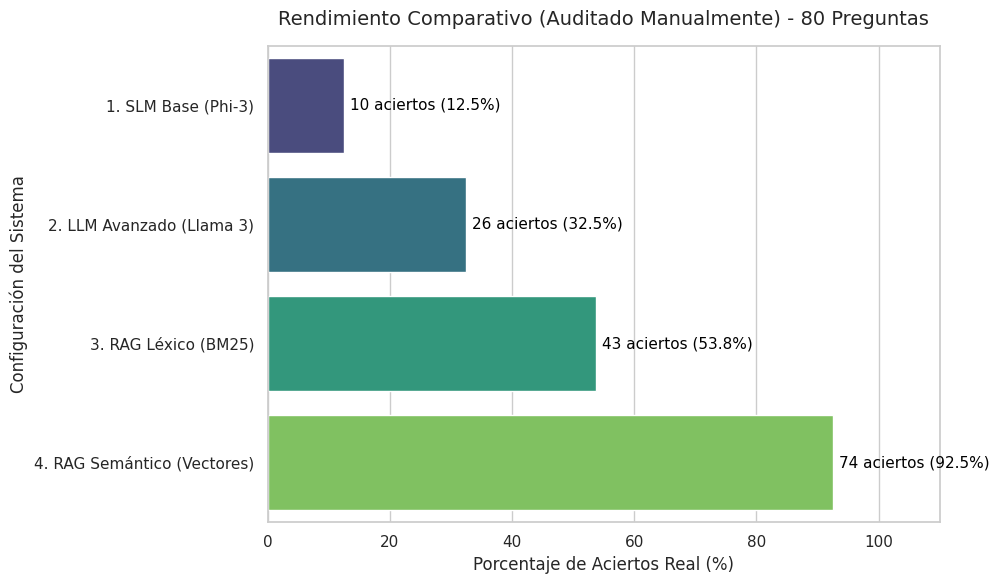

In [4]:
### GRAFICO CON LOS RESULTADOS CORREGIDOS MANUALMENTE ###
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


ruta_csv_corregido = "resultados_evaluacion_tfg_inicial_corregido.csv"
df_corregido = pd.read_csv(ruta_csv_corregido, sep=";")

print(f"Cargado el archivo corregido con {len(df_corregido)} preguntas evaluadas.")

# 2. Contar los aciertos (CORRECTO) de cada modelo
aciertos_manuales = {
    "1. SLM Base (Phi-3)": (df_corregido['C1_Eval'].str.strip().str.upper() == 'CORRECTO').sum(),
    "2. LLM Avanzado (Llama 3)": (df_corregido['C2_Eval'].str.strip().str.upper() == 'CORRECTO').sum(),
    "3. RAG Léxico (BM25)": (df_corregido['C3_Eval'].str.strip().str.upper() == 'CORRECTO').sum(),
    "4. RAG Semántico (Vectores)": (df_corregido['C4_Eval'].str.strip().str.upper() == 'CORRECTO').sum()
}

# 3. Preparar los datos para el gráfico
nombres = list(aciertos_manuales.keys())
valores = list(aciertos_manuales.values())
total_preguntas = len(df_corregido)
porcentajes = [(v / total_preguntas) * 100 for v in valores]

# 4. Crear el gráfico con estilo profesional
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x=porcentajes, y=nombres, palette="viridis")

# Añadir las etiquetas con el número exacto y el porcentaje
for p, val, perc in zip(ax.patches, valores, porcentajes):
    ax.annotate(f"{val} aciertos ({perc:.1f}%)", 
                (p.get_width() + 1, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=11, color='black')

plt.xlim(0, 110) # Damos margen a la derecha para que quepa el texto
plt.title(f'Rendimiento Comparativo (Auditado Manualmente) - {total_preguntas} Preguntas', fontsize=14, pad=15)
plt.xlabel('Porcentaje de Aciertos Real (%)', fontsize=12)
plt.ylabel('Configuración del Sistema', fontsize=12)
plt.tight_layout()

# Guardar el gráfico como imagen para pegarlo directo en el PDF de tu TFG
plt.savefig("grafico_rendimiento_corregido_tfg.png", dpi=300)
plt.show()